# Experiment Plotter

In [2]:
import pandas as pd
import numpy as np
from scipy import constants

## Unpack Data

In [3]:
df = pd.read_csv('/Users/omalleysherlock/Developer/OFDM-Sense/experiments/delay_experiment.csv')

actual_distance = df['actual distance(m)']

calculated_delay = df['calculated delay(ns)']

distance0 = df['calculated distance(m)']

# Experiment 2

In [4]:
df = pd.read_csv('/Users/omalleysherlock/Developer/OFDM-Sense/experiments/no_ref_2rx_01.csv')

delay0 = df['delay0']
distance0 = df['distance0']

delay1 = df['delay1']
distance1 = df['distance1']

evm0 = df['evm0']
evm1 = df['evm1']

ser0 = df['ser0']
ser1 = df['ser1']

ber0 = df['ber0']
ber1 = df['ber1']

actual_distance = np.linspace(110, 50, len(delay0))

Q1 = df['delay0'].quantile(0.25)
Q3 = df['delay0'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the entire dataframe to keep rows where delay0 is within bounds
df_cleaned = df[(df['delay0'] >= lower_bound) & (df['delay0'] <= upper_bound)].copy()

# Re-assign your variables from the cleaned dataframe
delay0_clean = df_cleaned['delay0']
distance0_clean = df_cleaned['distance0']
# ... and so on

# Calculate Angle

In [5]:
d = 0.1 #Distance between RX modules
C = constants.c
for i in range(len(delay0)):
    delta_t = (delay0[i] * 1e-9) - (delay1[i] * 1e-9)
    val = (delta_t * C) / d
    print(val)
    theta = np.arcsin((delta_t * C)/ d)
    print(theta)


11.092320946004008
nan
11.392113404024979
nan
14.09024552605121
nan
12.291490777966008
nan
12.89107569400795
nan
12.591283236027607
nan
11.691905862005322
nan
11.691905862005322
nan
10.792528487983034
nan
11.991698319985664
nan
12.291490777966008
nan
12.89107569400795
nan
11.991698319985664
nan
12.291490778006636
nan
10.792528487983034
nan
11.392113404024979
nan
10.19294357198172
nan
10.792528488023665
nan
12.291490778006636
nan
10.49273603000269
nan
12.291490778047267
nan
13.190868151988294
nan
11.392113404024979
nan
10.792528488023665
nan
10.792528488023665
nan
11.092320946004008
nan
11.392113404024979
nan
11.392113404024979
nan
10.19294357198172
nan
10.792528487942405
nan
10.792528487942405
nan
10.792528487942405
nan
11.092320946004008
nan
11.691905861964692
nan
11.39211340394372
nan
9.893151113960748
nan
10.19294357198172
nan
10.792528487942405
nan
11.991698319985664
nan
11.991698319985664
nan
11.991698319985664
nan
11.392113404024979
nan
10.792528487983034
nan
11.991698320026293
n

/var/folders/p7/p_9cgcc968xcbtfbxm8sv95m0000gn/T/ipykernel_88273/1752691345.py:7: RuntimeWarning: invalid value encountered in arcsin
  theta = np.arcsin((delta_t * C)/ d)


## Plot Data 

In [6]:
import matplotlib.pyplot as plt

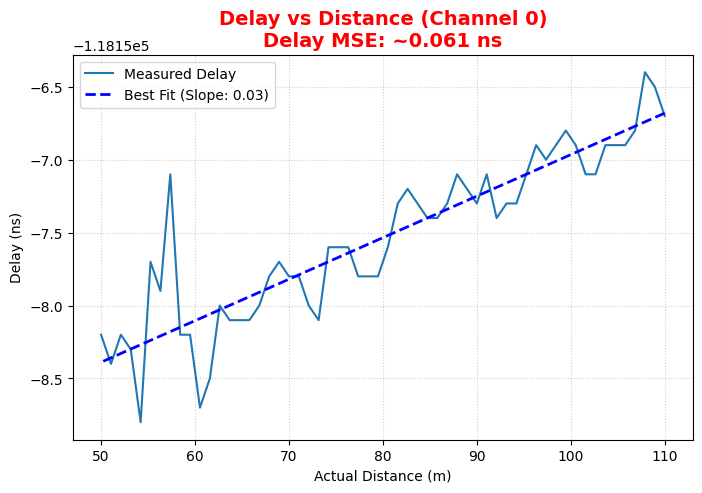

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

delay = delay0_clean
actual_distance = np.linspace(110,50,len(delay))

# 1. Calculate Line of Best Fit
# This creates the "Predicted" values (line_of_best_fit)
m, b = np.polyfit(actual_distance, delay, 1)
line_of_best_fit = m * actual_distance + b

# 2. Calculate MSE 
mse = mean_squared_error(delay, line_of_best_fit)

# 3. Plotting
plt.figure(figsize=(8, 5))

# Original Data
plt.plot(actual_distance, delay, label='Measured Delay')

# Line of Best Fit
plt.plot(actual_distance, line_of_best_fit, color='blue', linestyle='--', 
         linewidth=2, label=f'Best Fit (Slope: {m:.2f})')

plt.title(f"Delay vs Distance (Channel 0)\nDelay MSE: ~{mse:.3f} ns", fontsize=14, color='red', fontweight='bold')
plt.xlabel("Actual Distance (m)")
plt.ylabel("Delay (ns)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

# Plot Calced Distance Data

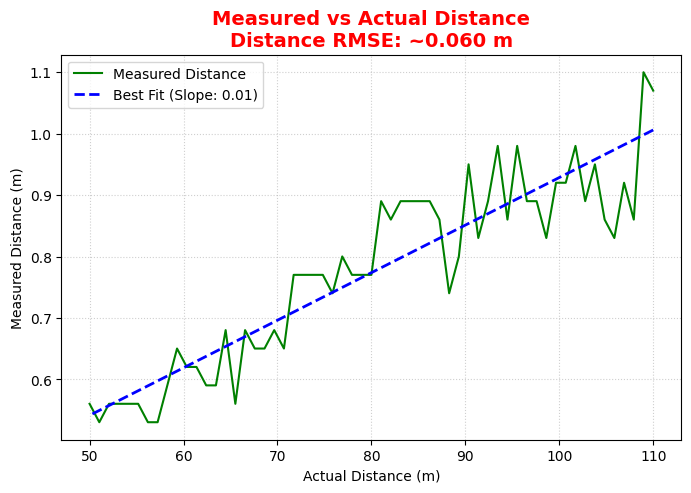

In [29]:
# Calculate Line of Best Fit
m, b = np.polyfit(actual_distance, distance1, 1)
line_of_best_fit = m * actual_distance + b

# Calculate MSE and then RMSE
mse = mean_squared_error(distance1, line_of_best_fit)
rmse = np.sqrt(mse)  # Convert to meters

# Plotting
plt.figure(figsize=(8, 5))

# Original Data
plt.plot(actual_distance, distance1, color='green', label='Measured Distance')

# Line of Best Fit
plt.plot(actual_distance, line_of_best_fit, color='blue', linestyle='--', 
         linewidth=2, label=f'Best Fit (Slope: {m:.2f})')

# UPDATED: Title says "Distance" and uses RMSE for "m" units
plt.title(f"Measured vs Actual Distance\nDistance RMSE: ~{rmse:.3f} m", fontsize=14, color='red', fontweight='bold')

plt.xlabel("Actual Distance (m)")
plt.ylabel("Measured Distance (m)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

# PLOT METRICS

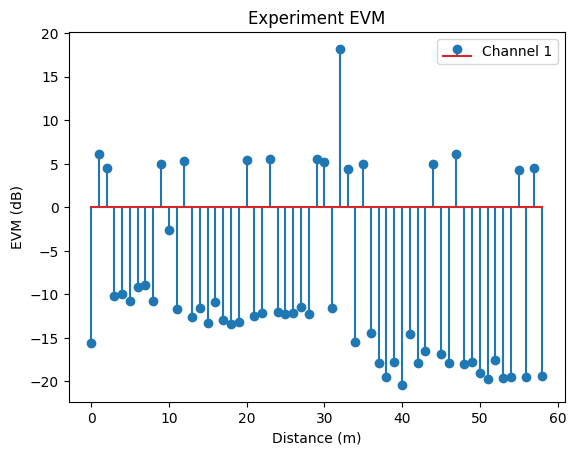

Average Channel 1 EVM:-10.671729993606103, Average Channel 1 -9.195889926258344


In [24]:

plt.figure()

#plt.stem(evm0, label = "Channel 0")
plt.stem(evm1, label = "Channel 1")
plt.legend()
plt.title("Experiment EVM")
plt.xlabel("Distance (m)")
plt.ylabel("EVM (dB)")
plt.show()

average_evm0 = np.average(evm0)
average_evm1 = np.average(evm1)

print(f"Average Channel 1 EVM:{average_evm0}, Average Channel 1 {average_evm1}")
 

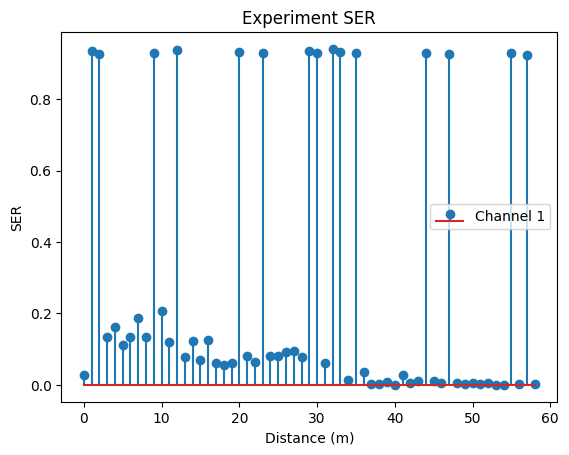

Average Channel 1 EVM:0.2803176057413345, Average Channel 1 0.2803176057413345


In [22]:

plt.figure()

#plt.stem(ser0, label = "Channel 0")
plt.stem(ser1, label = "Channel 1")
plt.legend()
plt.title("Experiment SER")
plt.xlabel("Distance (m)")
plt.ylabel("SER")
plt.show()

average_ser0 = np.average(ser0)
average_ser1 = np.average(ser1)

print(f"Average Channel 1 EVM:{average_ser1}, Average Channel 1 {average_ser1}")

# 

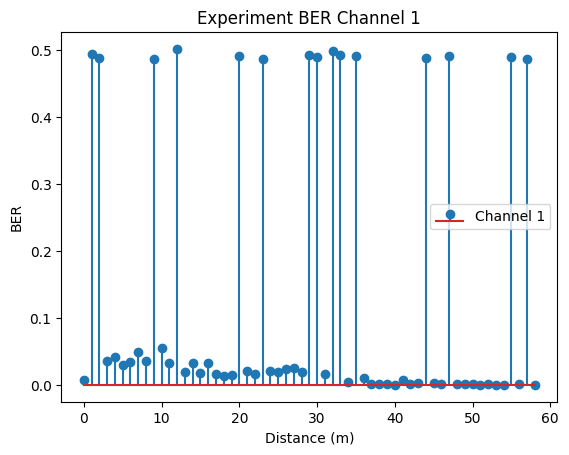

Average Channel ` EVM:0.1363605130554283, Average Channel 1 0.1363605130554283


In [20]:
plt.figure()

#plt.stem(ber0, label = "Channel 0")
plt.stem(ber1, label = "Channel 1")
plt.legend()
plt.title("Experiment BER Channel 1")
plt.xlabel("Distance (m)")
plt.ylabel("BER")
plt.show()

average_ber0 = np.average(ber0)
average_ber1 = np.average(ber1)

print(f"Average Channel ` EVM:{average_ber1}, Average Channel 1 {average_ber1}")